In [9]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import numpy as np

from src.utils.kitti_dataset_motsio import KittiDataset

In [8]:
image_folder = "/ghome/group02/Lore/C5-Project/Week2/dataset/KITTI-MOTS/training"
annotations_folder = "/ghome/group02/Lore/C5-Project/Week2/dataset/KITTI-MOTS/instances_txt"
seqmap_file = "/ghome/group02/Lore/C5-Project/Week2/src/utils/train.seqmap"

dataset = KittiDataset(image_folder, annotations_folder, seqmap_file)

print("Dataset length:", len(dataset))

Loading seqmap...
Dataset length: 5027


In [5]:
image, target = dataset[0]

print("Image shape:", image.shape)
print("Masks shape:", target["masks"].shape)
print("Labels:", target["labels"])
print("Image dtype:", image.dtype)
print("Masks dtype:", target["masks"].dtype)
print("Labels dtype:", target["labels"].dtype)
print(dataset.samples[0][0])

Image shape: torch.Size([3, 375, 1242])
Masks shape: torch.Size([1, 375, 1242])
Labels: tensor([2])
Image dtype: torch.float32
Masks dtype: torch.uint8
Labels dtype: torch.int64
/ghome/group02/Lore/C5-Project/Week2/dataset/KITTI-MOTS/training/image_02/0000/000000.png


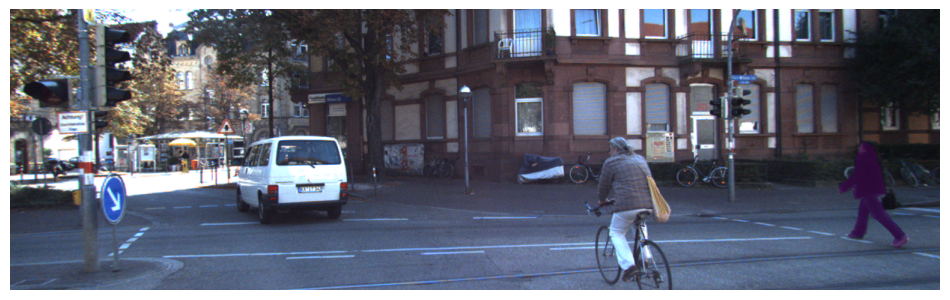

In [10]:
image, target = dataset[0]

img = image.permute(1,2,0).numpy()
masks = target["masks"].numpy()

plt.figure(figsize=(12,6))
plt.imshow(img)

for mask in masks:
    masked = np.ma.masked_where(mask == 0, mask)
    plt.imshow(masked, alpha=0.5)

plt.axis("off")
plt.show()

In [18]:
for i in [0, 1, 2, 10, 20]:
    if i >= len(dataset):
        continue

    image, target = dataset[i]
    print(f"\nSample {i}")
    print("  image shape:", image.shape)
    print("  masks shape:", target["masks"].shape)
    print("  labels:", target["labels"].tolist())
    print(dataset.samples[i][0])


Sample 0
  image shape: torch.Size([3, 375, 1242])
  masks shape: torch.Size([1, 375, 1242])
  labels: [2]
/ghome/group02/Lore/C5-Project/Week2/dataset/KITTI-MOTS/training/image_02/0000/000000.png

Sample 1
  image shape: torch.Size([3, 375, 1242])
  masks shape: torch.Size([1, 375, 1242])
  labels: [2]
/ghome/group02/Lore/C5-Project/Week2/dataset/KITTI-MOTS/training/image_02/0000/000001.png

Sample 2
  image shape: torch.Size([3, 375, 1242])
  masks shape: torch.Size([1, 375, 1242])
  labels: [2]
/ghome/group02/Lore/C5-Project/Week2/dataset/KITTI-MOTS/training/image_02/0000/000002.png

Sample 10
  image shape: torch.Size([3, 375, 1242])
  masks shape: torch.Size([0, 375, 1242])
  labels: []
/ghome/group02/Lore/C5-Project/Week2/dataset/KITTI-MOTS/training/image_02/0000/000010.png

Sample 20
  image shape: torch.Size([3, 375, 1242])
  masks shape: torch.Size([0, 375, 1242])
  labels: []
/ghome/group02/Lore/C5-Project/Week2/dataset/KITTI-MOTS/training/image_02/0000/000020.png


In [14]:
for i in range(min(50, len(dataset))):
    _, target = dataset[i]
    labels = target["labels"].tolist()

    for label in labels:
        assert label in [1, 2], f"Unexpected label {label} in sample {i}"

print("All checked labels are valid.")

All checked labels are valid.


In [15]:
for i in range(min(50, len(dataset))):
    image, target = dataset[i]
    _, h, w = image.shape
    masks = target["masks"]

    if masks.shape[0] > 0:
        assert masks.shape[1] == h, f"Mask height mismatch in sample {i}"
        assert masks.shape[2] == w, f"Mask width mismatch in sample {i}"

print("All checked mask sizes match the image size.")

All checked mask sizes match the image size.


In [16]:
for i in range(min(50, len(dataset))):
    _, target = dataset[i]
    masks = target["masks"]

    for j in range(masks.shape[0]):
        area = masks[j].sum().item()
        assert area > 0, f"Empty mask found in sample {i}, object {j}"

print("All checked masks have non-zero area.")

All checked masks have non-zero area.
